In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Cleaning and Understanding

In [2]:
df = pd.read_csv('data/dauerzaehlstellen.csv', sep=';', encoding='latin-1')
df.head()

,JAHR,MONAT,ZNR,ZNAME,STRTYP,STRNR,RINAME,FZTYP,DTVMS,DTVMF,DTVMO,DTVDD,DTVFR,DTVSA,DTVSF,TVMAX,TVMAXT
0,2025,MÄRZ,1075,Reichsbrücke,B,8,Leopoldstadt,Kfz,26977,28544,28550,28126,29791,24767,22602,47760,"Do,27.03."
1,2025,MÄRZ,1075,Reichsbrücke,B,8,Leopoldstadt,LkwÄ,1674,1688,1846,1590,1782,1657,1634,5081,"So,30.03."
2,2025,MÄRZ,1075,Reichsbrücke,B,8,Donaustadt,Kfz,16067,17416,16563,17705,17615,14382,12089,19871,"Do,20.03."
3,2025,MÄRZ,1075,Reichsbrücke,B,8,Donaustadt,LkwÄ,282,365,371,381,310,121,96,462,"Di,25.03."
4,2025,MÄRZ,1075,Reichsbrücke,B,8,Gesamt,Kfz,43044,45960,45112,45831,47406,39150,34691,66394,"Do,27.03."


## Drop columns and rows not needed for the analysis

- `ZNR` and `ZNAME` identify the measurement station, with one being an int and the other a string. The columns are redundant, so drop `ZNAME`.
- Keep only `DTVMS` and drop the rest of the traffic count columns since only interested in the average, daily traffic counts for all days of the week.
- Select rows where `FZTYP` == `Kfz` since only want to work with total traffic counts, then drop the column.

In [3]:
drop_cols = ['ZNAME', 'DTVMF', 'DTVMO', 'DTVDD', 'DTVFR', 'FZTYP', 'DTVSA', 'DTVSF', 'TVMAX', 'TVMAXT']
df = (df[df['FZTYP'] == 'Kfz']
      .drop(columns=drop_cols)
      .reset_index(drop=True)
      )

## Convert MONAT column from string to int

In [4]:
monat_map = {'jan': 1, 'feb' : 2,  'märz': 3,  'april': 4,
             'mai': 5, 'juni': 6,  'juli': 7,  'aug'  : 8,
             'sep': 9, 'okt' : 10, 'nov' : 11, 'dez'  : 12}

df['MONAT'] = (
    df['MONAT'].str.rstrip('.')
    .str.lower()
    .map(monat_map)
)

df.head()

,JAHR,MONAT,ZNR,STRTYP,STRNR,RINAME,DTVMS
0,2025,3,1075,B,8,Leopoldstadt,26977
1,2025,3,1075,B,8,Donaustadt,16067
2,2025,3,1075,B,8,Gesamt,43044
3,2025,3,1078,B,221,Wienzeile,36497
4,2025,3,1078,B,221,Stadthalle,32686


## Check for missing values

In [5]:
df.isnull().sum()

JAHR      0
MONAT     0
ZNR       0
STRTYP    0
STRNR     0
RINAME    0
DTVMS     0
dtype: int64

## Get summary statistics

In [6]:
df.describe()

,JAHR,MONAT,ZNR,STRNR,DTVMS
count,22836.000000,22836.000000,22836.000000,22836.000000,22836.000000
mean,2020.245665,6.377430,1317.601550,64.335523,12512.686241
std,2.645973,3.487058,197.953473,98.986129,11024.950135
min,2016.000000,1.000000,1075.000000,0.000000,-29.000000
25%,2018.000000,3.000000,1192.000000,0.000000,6105.000000
50%,2020.000000,6.000000,1209.000000,3.000000,9577.000000
75%,2023.000000,9.000000,1608.000000,221.000000,16214.250000
max,2025.000000,12.000000,1627.000000,230.000000,78250.000000


There seems to be some records with negative values for traffic counts. Report all distinct negative values for `DTVMS`.

In [7]:
df[df['DTVMS'] < 0]['DTVMS'].unique()

array([-29])

The metadata says that records are assigned a value of -29 if no valid measurement was taken. Therefore, drop these records.

In [8]:
df = df[df['DTVMS'] >= 0]

## Create datetime column for plotting

In [9]:
df['timestamp'] = df['JAHR'].astype(str) + ' ' + df['MONAT'].astype(str)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y %m')
df = df.sort_values(by=['ZNR', 'RINAME', 'timestamp'])

### Plot `DTVMS` for a given `ZNR` and `RINAME` to determine how the data looks

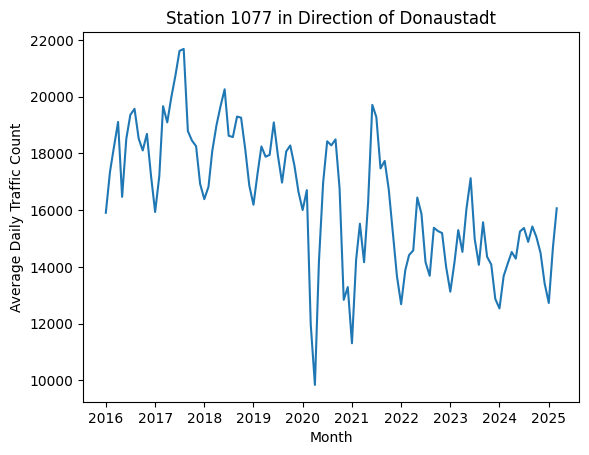

In [10]:
df_slice = df[(df['ZNR'] == 1075) & (df['RINAME'] == 'Donaustadt')]
plt.plot(df_slice['timestamp'], df_slice['DTVMS'])
plt.title('Station 1077 in Direction of Donaustadt')
plt.xlabel('Month')
plt.ylabel('Average Daily Traffic Count')
plt.show()